In [5]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

10

,filename,code
2,./nbody.wast,1120
4,./fankuchredux.wast,545
5,./mandelbrot.wast,525
6,./reverse-complement.wast,314
7,./fasta.wast,294
8,./binarytrees.wast,255


,code
count,6.000000
mean,508.833333
std,323.616697
min,255.000000
25%,299.000000
50%,419.500000
75%,540.000000
max,1120.000000


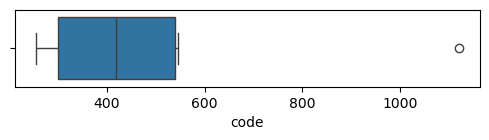

In [11]:
df = pd.read_csv("sturdy-wasm/src/test/resources/sturdy/language/wasm/benchmarksgame/src/loc.csv")
display(len(df))
df = df[
    (df['filename'] == './binarytrees.wast') | 
    (df['filename'] == './fankuchredux.wast') | 
    (df['filename'] == './fasta.wast') | 
    (df['filename'] == './mandelbrot.wast') |
    (df['filename'] == './nbody.wast') |
    (df['filename'] == './reverse-complement.wast')
]
df = df[['filename', 'code']]
display(df)
display(df.describe())

fig, ax = plt.subplots(figsize=(6, 1))
sns.boxplot(df, x = 'code',  ax=ax)
plt.savefig("benchmarksgame_loc.png",  bbox_inches="tight", dpi=300)

In [36]:
df = pd.read_csv("benchmarks-game-performance-test.csv")
df['time'] = df['time'] / 1e9

<Axes: xlabel='program', ylabel='time'>

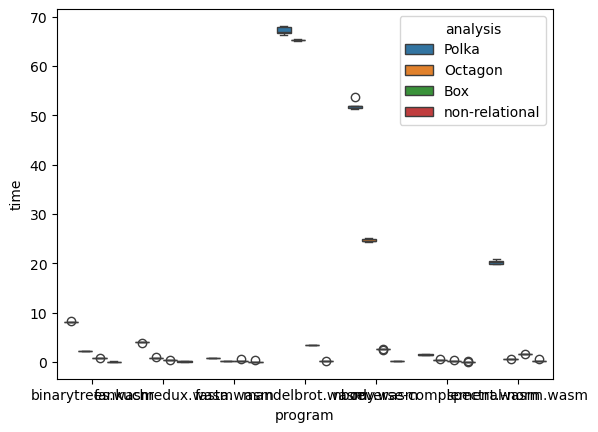

In [37]:
sns.boxplot(df, x = 'program', y = 'time', hue = 'analysis')

run  env_size  byte_size        time
analysis program                                                      
Octagon  binarytrees.wasm         3.0      47.0     4512.0  488.389390
Polka    binarytrees.wasm         3.0      47.0    21956.0    8.130658
         fankuchredux.wasm        3.0      51.0     3723.0    4.051589
         fasta.wasm               3.0      36.0     2848.0    0.818258
         mandelbrot.wasm          3.0     113.0    15873.0   65.627831
         nbody.wasm               3.0     147.0    24108.0   51.857638
         reverse-complement.wasm  3.0      51.0     8096.0    1.567304
         spectral-norm.wasm       3.0      58.0     3770.0   19.893536

<Axes: xlabel='env_size', ylabel='time'>

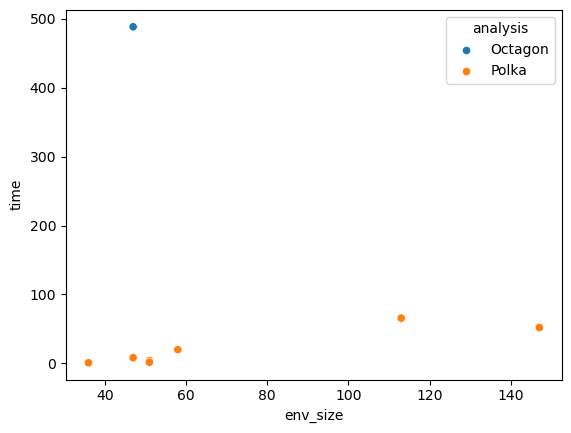

In [32]:
df = df.groupby(by=['analysis','program']).mean()
display(df)

sns.scatterplot(df, x = 'env_size', y = 'time', hue = 'analysis')